# 🛡️ EDA — Cybersécurité IT/OT Marine Nationale

**Dataset :** `neo4j_dataset_50k` — graphe d'événements et d'actifs d'un système d'information naval hybride IT/OT.

**Objectif de cette EDA :**
1. Comprendre la topologie du SI (assets, dépendances)
2. Caractériser le trafic d'événements normal vs anormal
3. Identifier les chemins d'attaque potentiels IT → OT
4. Préparer les éléments factuels du *Strategic Pitch* (Deliverable 1)

**Structure des données (modèle graphe) :**
- **Nodes** : `assets` (65), `events` (50 000), `attacks` (1)
- **Relations** : `DEPENDS_ON`, `GENERATED`, `TARGETS`, `INCLUDES`

## 0. Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)

DATA_DIR = Path("neo4j_dataset_50k (1)")

assets       = pd.read_csv(DATA_DIR / "nodes_assets.csv")
events       = pd.read_csv(DATA_DIR / "nodes_events.csv", parse_dates=["timestamp"])
attacks      = pd.read_csv(DATA_DIR / "nodes_attacks.csv", parse_dates=["start_time", "end_time"])
dependencies = pd.read_csv(DATA_DIR / "rels_dependencies.csv")
generated    = pd.read_csv(DATA_DIR / "rels_generated.csv")
includes     = pd.read_csv(DATA_DIR / "rels_includes.csv")
targets      = pd.read_csv(DATA_DIR / "rels_targets.csv")

print(f"Assets       : {len(assets):>6}")
print(f"Events       : {len(events):>6}")
print(f"Attacks      : {len(attacks):>6}")
print(f"Dependencies : {len(dependencies):>6}")
print(f"Generated    : {len(generated):>6}")
print(f"Includes     : {len(includes):>6}")
print(f"Targets      : {len(targets):>6}")

Assets       :     65
Events       :  50000
Attacks      :      1
Dependencies :     50
Generated    :  50000
Includes     :  10000
Targets      :  50000


## 1. Topologie du système d'information

Le SI mélange un environnement **IT** (postes utilisateurs, serveurs web) et un environnement **OT** (Operational Technology) avec interfaces homme-machine et automates programmables. C'est exactement l'architecture d'un **navire moderne** : la passerelle, les systèmes de gestion administrative et les automates de propulsion / d'armes cohabitent.

In [2]:
print("Répartition par type d'actif :")
print(assets["type"].value_counts(), end="\n\n")
print("Répartition par rôle :")
print(assets["role"].value_counts(), end="\n\n")
print("CPE (logiciel/OS) unique :")
print(assets["cpe"].value_counts())

Répartition par type d'actif :
type
workstation    30
server         15
HMI            10
PLC            10
Name: count, dtype: int64

Répartition par rôle :
role
user_endpoint         30
web_server            15
operator_interface    10
controller            10
Name: count, dtype: int64

CPE (logiciel/OS) unique :
cpe
cpe:2.3:o:microsoft:windows_10:22h2:*:*:*:*:*:*:*    30
cpe:2.3:a:apache:http_server:2.4.52:*:*:*:*:*:*:*    15
cpe:2.3:a:siemens:wincc:*:*:*:*:*:*:*:*              10
cpe:2.3:h:siemens:s7-1200:*:*:*:*:*:*:*:*            10
Name: count, dtype: int64


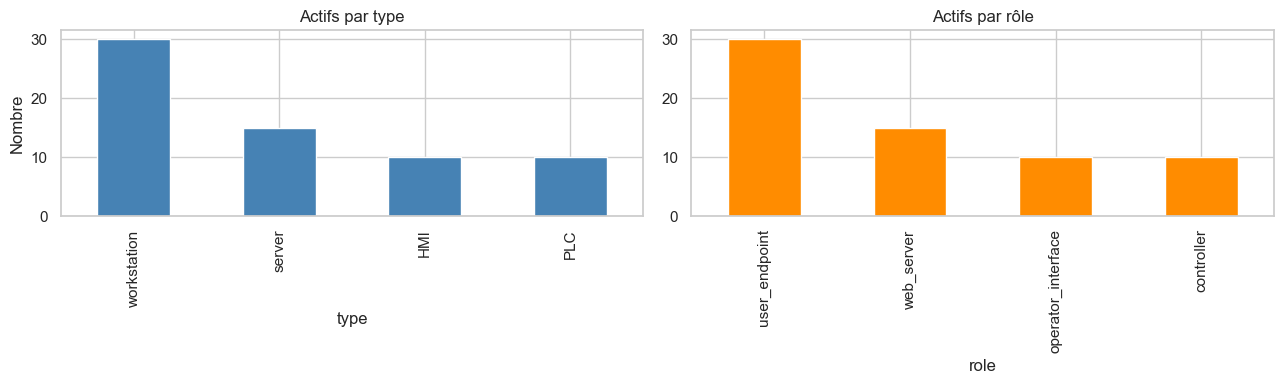

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
assets["type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Actifs par type")
axes[0].set_ylabel("Nombre")
assets["role"].value_counts().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Actifs par rôle")
plt.tight_layout(); plt.show()

### 1.1 Graphe de dépendances IT → OT

Le modèle **Purdue** (référence en sécurité industrielle) est ici reproduit :
`Workstation → Serveur → HMI → PLC`

Cette chaîne est l'**autoroute d'une cyberattaque** : un poste compromis peut, via les dépendances, atteindre un automate qui pilote un système physique (vanne, moteur, capteur).

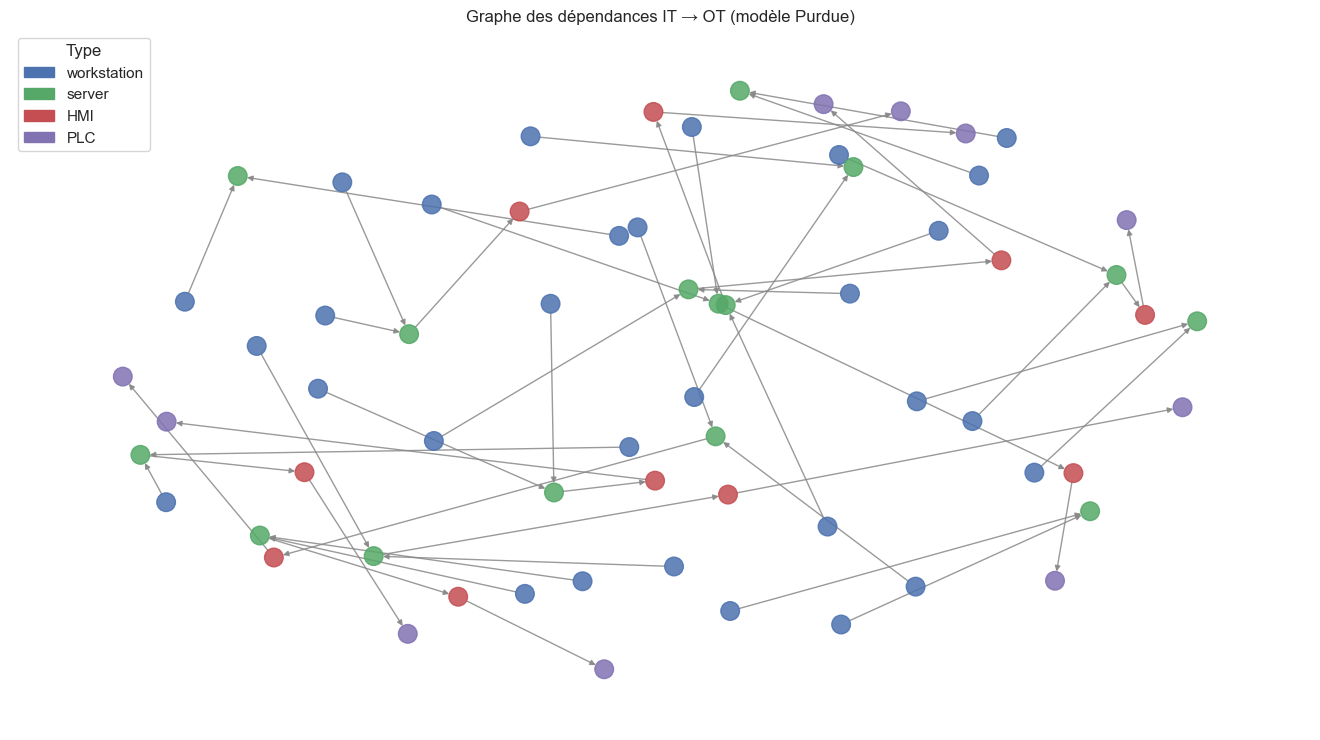

Degré entrant max (asset le plus dépendant de) :
IT-SRV-13    2
IT-SRV-10    2
IT-SRV-14    2
IT-SRV-03    2
IT-SRV-12    2
dtype: int64


In [4]:
G = nx.from_pandas_edgelist(
    dependencies, source=":START_ID", target=":END_ID", create_using=nx.DiGraph
)
for _, row in assets.iterrows():
    if row["asset_id:ID"] in G:
        G.nodes[row["asset_id:ID"]]["type"] = row["type"]

color_map = {"workstation": "#4C72B0", "server": "#55A868",
             "HMI": "#C44E52", "PLC": "#8172B2"}
node_colors = [color_map.get(G.nodes[n].get("type"), "#999999") for n in G.nodes]

plt.figure(figsize=(13, 7))
pos = nx.spring_layout(G, seed=42, k=0.6)
nx.draw(G, pos, node_color=node_colors, node_size=180, with_labels=False,
        edge_color="#888", arrows=True, arrowsize=8, alpha=0.85)
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=c, label=t) for t, c in color_map.items()],
           loc="upper left", title="Type")
plt.title("Graphe des dépendances IT → OT (modèle Purdue)"); plt.show()

print("Degré entrant max (asset le plus dépendant de) :")
print(pd.Series(dict(G.in_degree())).sort_values(ascending=False).head(5))

## 2. Caractérisation des événements

50 000 événements sur ~14 heures de simulation. Six types : `file_access`, `http_request`, `login`, `modbus_write`, `read_sensor`, `exploit_attempt`.

In [5]:
print("Période couverte :", events["timestamp"].min(), "→", events["timestamp"].max())
print("Durée totale     :", events["timestamp"].max() - events["timestamp"].min())
print()
print("Distribution event_type / status :")
ct = pd.crosstab(events["event_type"], events["status"])
ct["% anomalies"] = (ct.get("anomalous", 0) / ct.sum(axis=1) * 100).round(2)
ct

Période couverte : 2026-05-01 10:00:00+00:00 → 2026-05-01 23:53:19+00:00
Durée totale     : 0 days 13:53:19

Distribution event_type / status :


status,anomalous,normal,% anomalies
event_type,,,
exploit_attempt,2446,0,100.0
file_access,0,9699,0.0
http_request,0,9436,0.0
login,0,9417,0.0
modbus_write,0,9433,0.0
read_sensor,0,9569,0.0


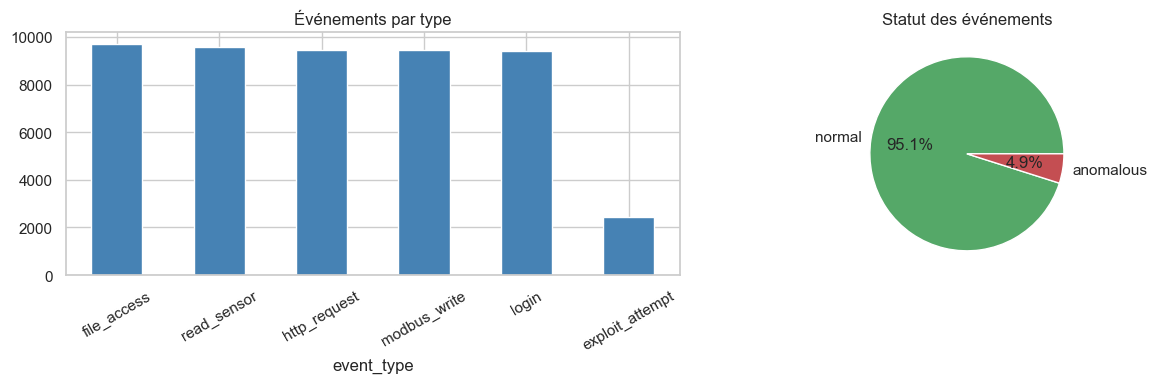

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
events["event_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Événements par type"); axes[0].tick_params(axis="x", rotation=30)
events["status"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.1f%%",
                                      colors=["#55A868", "#C44E52"])
axes[1].set_title("Statut des événements"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

### 2.1 Série temporelle — où se cache l'attaque ?

L'attaque déclarée `ATTACK-001` se déroule de **11:00 à 15:00 UTC** le 1er mai 2026. Les 2 446 événements anomaux (4,9 % du total) correspondent **tous** à des `exploit_attempt` exploitant `CVE-2021-41773` (Apache HTTP path traversal).

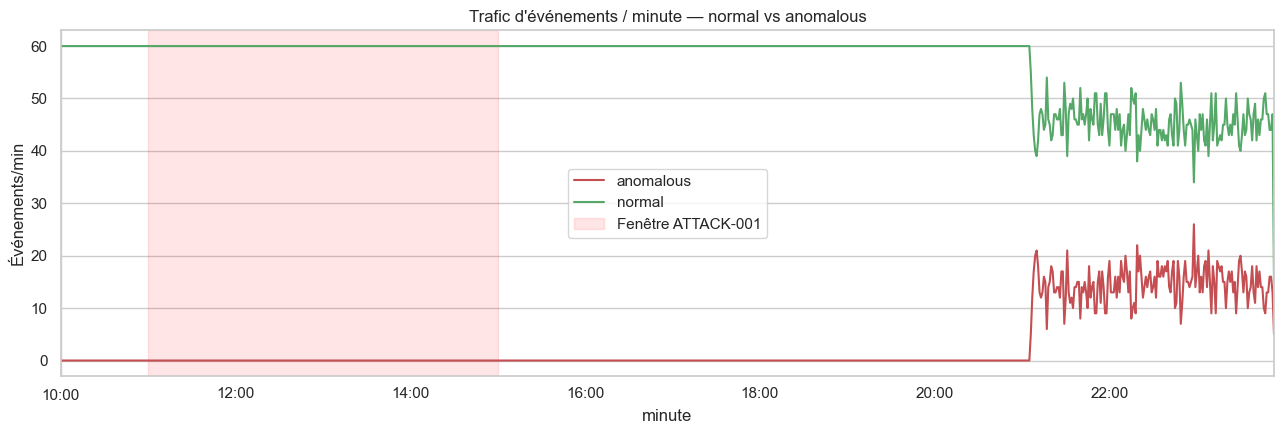

In [7]:
ev = events.copy()
ev["minute"] = ev["timestamp"].dt.floor("min")
ts = ev.groupby(["minute", "status"]).size().unstack(fill_value=0)

ax = ts.plot(figsize=(13, 4.5), color={"normal": "#55A868", "anomalous": "#C44E52"})
ax.axvspan(attacks["start_time"].iloc[0], attacks["end_time"].iloc[0],
           color="red", alpha=0.10, label="Fenêtre ATTACK-001")
ax.set_title("Trafic d'événements / minute — normal vs anomalous")
ax.set_ylabel("Événements/min"); ax.legend(); plt.tight_layout(); plt.show()

In [8]:
anom = events[events["status"] == "anomalous"]
print("Anomalies par type :")
print(anom["event_type"].value_counts())
print("\nCVE référencées dans les anomalies :")
print(anom["cve"].value_counts())

Anomalies par type :
event_type
exploit_attempt    2446
Name: count, dtype: int64

CVE référencées dans les anomalies :
cve
CVE-2021-41773    2446
Name: count, dtype: int64


### 2.2 Surface d'attaque — quelles cibles ?

In [9]:
ev_target = events.merge(targets, left_on="event_id:ID", right_on=":START_ID")
ev_target = ev_target.merge(assets, left_on=":END_ID", right_on="asset_id:ID")

anom_by_target = (ev_target[ev_target["status"] == "anomalous"]
                  .groupby(["type", "role"]).size()
                  .reset_index(name="nb_anomalies")
                  .sort_values("nb_anomalies", ascending=False))
print("Anomalies par type d'actif ciblé :")
print(anom_by_target)

Anomalies par type d'actif ciblé :
          type                role  nb_anomalies
3  workstation       user_endpoint          1171
2       server          web_server           546
0          HMI  operator_interface           372
1          PLC          controller           357


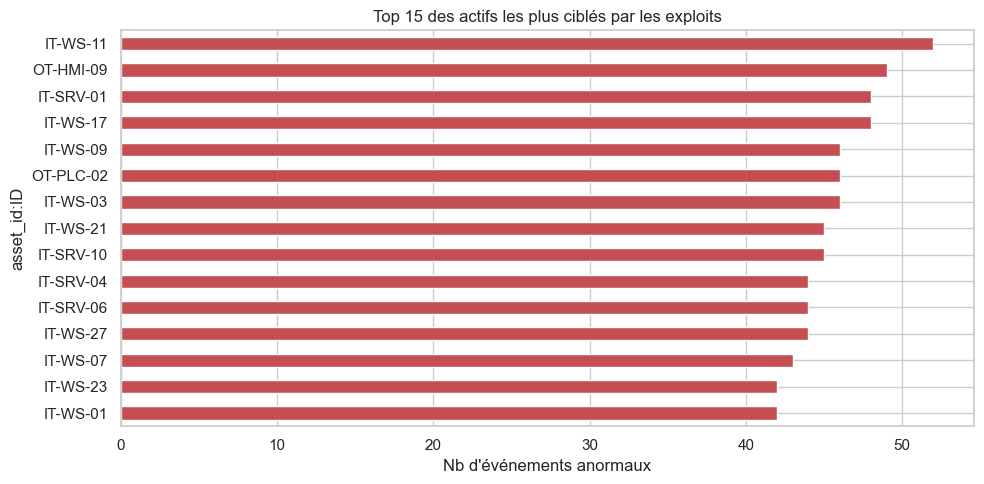

In [10]:
top_targets = (ev_target[ev_target["status"] == "anomalous"]
               .groupby("asset_id:ID").size().sort_values(ascending=False).head(15))
top_targets.plot(kind="barh", color="#C44E52", figsize=(10, 5))
plt.gca().invert_yaxis()
plt.title("Top 15 des actifs les plus ciblés par les exploits")
plt.xlabel("Nb d'événements anormaux"); plt.tight_layout(); plt.show()

### 2.3 Propagation IT → OT — la vraie menace

Question clef : **un compromis sur un actif IT touche-t-il aussi des actifs OT** via les dépendances ?

In [11]:
compromised = set(ev_target.loc[ev_target["status"] == "anomalous", "asset_id:ID"])
reachable_ot = set()
for src in compromised:
    if src in G:
        for tgt in nx.descendants(G, src):
            t = G.nodes[tgt].get("type")
            if t in ("HMI", "PLC"):
                reachable_ot.add(tgt)

print(f"Actifs compromis (ciblés par >=1 exploit) : {len(compromised)}")
print(f"Actifs OT atteignables depuis un compromis : {len(reachable_ot)}")
print(f"  → soit {len(reachable_ot)}/20 OT exposés indirectement")

Actifs compromis (ciblés par >=1 exploit) : 65
Actifs OT atteignables depuis un compromis : 20
  → soit 20/20 OT exposés indirectement


### 2.4 Valeurs Modbus — capteurs anormaux ?

Les écritures `modbus_write` portent une valeur (consigne envoyée à un automate). Une consigne hors plage peut endommager un équipement physique.

count    19002.000000
mean        79.779129
std         23.495018
min         40.000000
25%         59.000000
50%         80.000000
75%        100.000000
max        120.000000
Name: value, dtype: float64


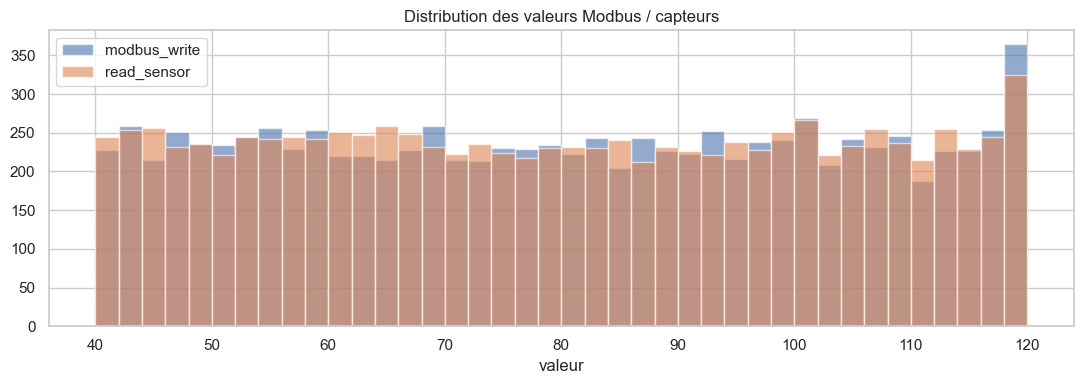

In [12]:
mb = events[events["event_type"].isin(["modbus_write", "read_sensor"])].dropna(subset=["value"])
print(mb["value"].describe())

fig, ax = plt.subplots(figsize=(11, 4))
for et, color in [("modbus_write", "#4C72B0"), ("read_sensor", "#DD8452")]:
    ax.hist(mb.loc[mb["event_type"] == et, "value"], bins=40,
            alpha=0.6, label=et, color=color)
ax.set_title("Distribution des valeurs Modbus / capteurs")
ax.set_xlabel("valeur"); ax.legend(); plt.tight_layout(); plt.show()

## 3. Synthèse pour le Strategic Pitch

| Constat EDA | Implication pour le pitch |
|---|---|
| 65 actifs IT/OT, dépendances Workstation→Server→HMI→PLC | Architecture-type d'un navire (Purdue). Une attaque IT peut paralyser un système OT critique. |
| 2 446 anomalies (4,9 %) toutes via `CVE-2021-41773` | Un seul exploit Apache suffit à générer un volume massif d'incidents → besoin de **détection précoce** et non d'audit a posteriori. |
| Pic d'anomalies 11:00–15:00 vs trafic normal | Le signal est noyé dans le bruit légitime (47 554 événements normaux). Nécessité d'une **détection contextuelle**, pas d'un seuil naïf. |
| Exploits ciblent serveurs web puis HMI via dépendances | **Cible métier** = empêcher l'attaque d'atteindre l'OT (propulsion, armes, navigation). |
| Données déjà modélisées en graphe Neo4j | **Levier technique** : algorithmes graphes (GNN, path scoring) plutôt que classifieurs tabulaires classiques. |

→ Voir le fichier `PITCH_STRATEGIQUE.md` pour le 1-pager candidat.